# Leaf Segmentation: RGB PCA vs. Excess Green Index (ExG)

This notebook compares two different segmentation approaches on the RGB color space:
1. **Standardized PCA (without Polarity Correction)**
2. **Excess Green Index (ExG)**

### Pipeline Steps for both approaches:
- **Feature Extraction**: Either project standardized RGB channels onto the first principal component (PC1), or compute the Excess Green Index ($2g - r - b$ using normalized chromaticities).
- **Otsu's Thresholding**: Binarize the scaled 0-255 feature map.
- **Morphological Cleaning**: Apply Opening followed by Closing using a 5x5 elliptical kernel.
- **Geometric Filtering**: Filter out background noise (like hydroponic channels) using area, aspect ratio, and width-spanning constraints.

In [112]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

%matplotlib inline

### Load Representative Image

We load a representative image from the `veg_2` category (`leaf-image/veg_2/IMG_7995.JPG`).

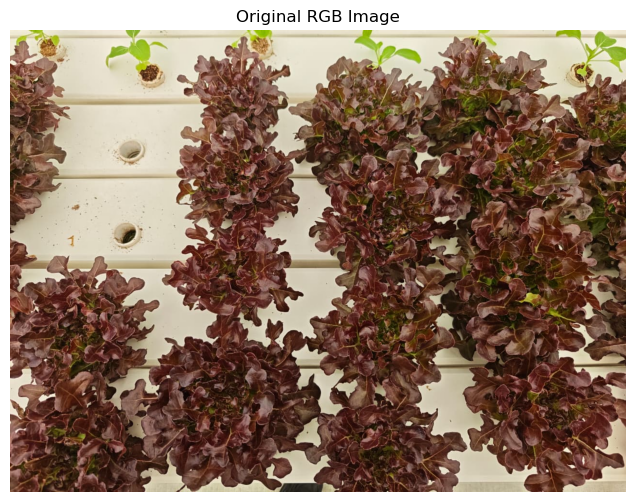

In [113]:
img_path = 'leaf-image/veg_3/IMG_8005.JPG'

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise FileNotFoundError(f"Could not locate the image at: {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis('off')
plt.show()

### Approach 1: Standardized PCA (No Polarity Correction)

Principle Component Analysis: PC1 vs (PC1 + PC2)
Rendering comparison grid...


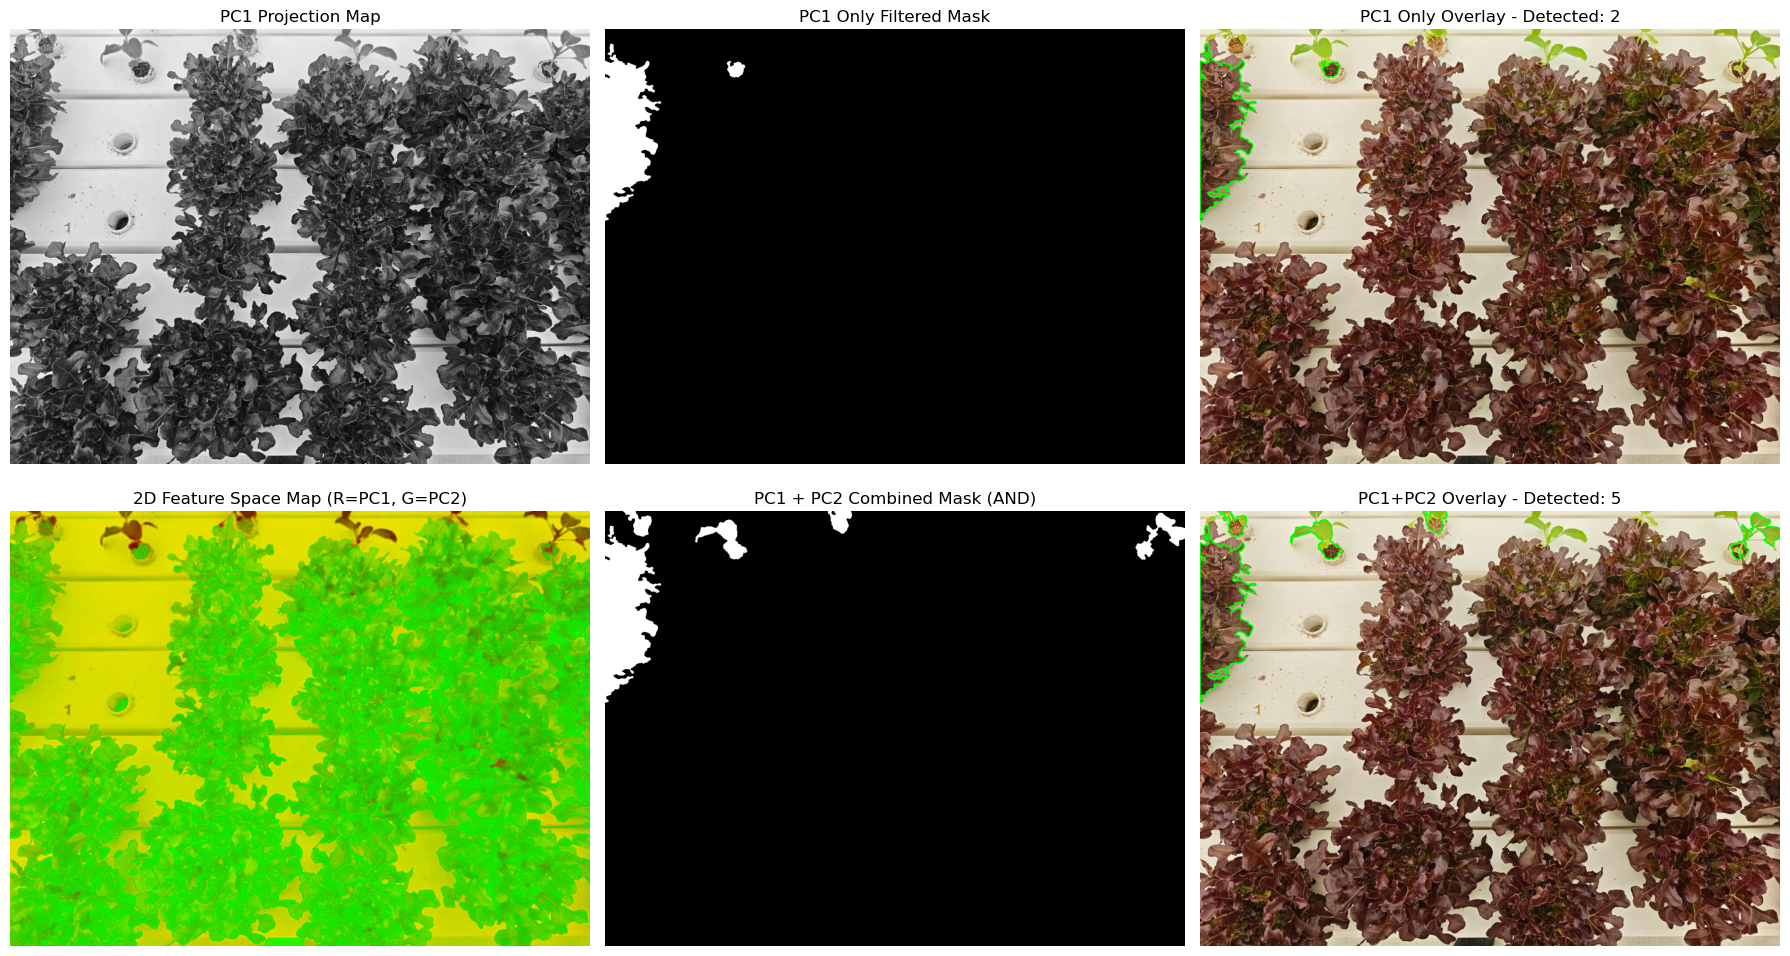

In [124]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("========================================")
print("Principle Component Analysis: PC1 vs (PC1 + PC2)")
print("========================================")

# 1. Reshape original image channels directly for PCA
features = img_rgb.reshape(-1, 3).astype(np.float32)

# 2. Run PCA using the lightweight compute function
mean, eigenvectors = cv2.PCACompute(features, mean=None)
projected = cv2.PCAProject(features, mean, eigenvectors)

# Extract BOTH PC1 and PC2 channels
pc1 = projected[:, 0].reshape(img_rgb.shape[:2])
pc2 = projected[:, 1].reshape(img_rgb.shape[:2])

# 3. Scale to 0-255 safely for both components
def scale_component(pc_array):
    pc_min, pc_max = pc_array.min(), pc_array.max()
    return np.uint8(255 * (pc_array - pc_min) / (pc_max - pc_min + 1e-8))

pc1_scaled = scale_component(pc1)
pc2_scaled = scale_component(pc2)

# 4. Helper function to perform thresholding, polarity fix, and morphology
def get_clean_binary_mask(pc_image):
    # Otsu's Thresholding
    _, thresh = cv2.threshold(pc_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Polarity Correction (Check corners to ensure background is black, plants are white)
    h_dim, w_dim = thresh.shape
    corners = [thresh[0, 0], thresh[0, w_dim-1], thresh[h_dim-1, 0], thresh[h_dim-1, w_dim-1]]
    if np.mean(corners) > 127:
        thresh = cv2.bitwise_not(thresh)
        
    # Morphological Cleaning
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    return cleaned

# Helper function to filter contours by size and draw overlay
def filter_and_draw_contours(binary_mask):
    contours_found, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered_mask = np.zeros_like(binary_mask)
    
    for cnt in contours_found:
        area = cv2.contourArea(cnt)
        if 800 <= area <= 120000:
            cv2.drawContours(filtered_mask, [cnt], -1, 255, -1)
            
    final_cnts, _ = cv2.findContours(filtered_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_overlay = img_rgb.copy()
    cv2.drawContours(contour_overlay, final_cnts, -1, (0, 255, 0), 2)
    
    return filtered_mask, contour_overlay, len(final_cnts)

# =========================================================================
# APPROACH 1: PC1 ALONE
# =========================================================================
raw_mask_pc1 = get_clean_binary_mask(pc1_scaled)
mask_pc1, overlay_pc1, count_pc1 = filter_and_draw_contours(raw_mask_pc1)

# =========================================================================
# APPROACH 2: PC1 + PC2 COMBINED (Logical Intersection)
# =========================================================================
# Generate individual binary masks for both components
raw_mask_pc1_for_combo = get_clean_binary_mask(pc1_scaled)
raw_mask_pc2_for_combo = get_clean_binary_mask(pc2_scaled)

# Combine them using bitwise AND (A pixel must be flagged as a plant in BOTH components)
combined_raw_mask = cv2.bitwise_or(raw_mask_pc1_for_combo, raw_mask_pc2_for_combo)
mask_combo, overlay_combo, count_combo = filter_and_draw_contours(combined_raw_mask)

# =========================================================================
# 5. Plot step results side-by-side in a 2x3 grid
# =========================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- ROW 1: PC1 Alone Results ---
axes[0, 0].imshow(pc1_scaled, cmap='gray')
axes[0, 0].set_title("PC1 Projection Map")
axes[0, 1].imshow(mask_pc1, cmap='gray')
axes[0, 1].set_title("PC1 Only Filtered Mask")
axes[0, 2].imshow(overlay_pc1)
axes[0, 2].set_title(f"PC1 Only Overlay - Detected: {count_pc1}")

# --- ROW 2: PC1 + PC2 Combined Results ---
# For visualization, we merge them into a mock color visualization map
combined_visual_map = cv2.merge([pc1_scaled, pc2_scaled, np.zeros_like(pc1_scaled)])
axes[1, 0].imshow(combined_visual_map)
axes[1, 0].set_title("2D Feature Space Map (R=PC1, G=PC2)")

axes[1, 1].imshow(mask_combo, cmap='gray')
axes[1, 1].set_title("PC1 + PC2 Combined Mask (AND)")
axes[1, 2].imshow(overlay_combo)
axes[1, 2].set_title(f"PC1+PC2 Overlay - Detected: {count_combo}")

# Turn off axes for all plots
for row in axes:
    for ax in row:
        ax.axis('off')

plt.tight_layout()
print("Rendering comparison grid...")
plt.show()

### Approach 2: Excess Green Index (ExG)

Excess Green Index: ExG
[ExG] Otsu threshold value: 109.0


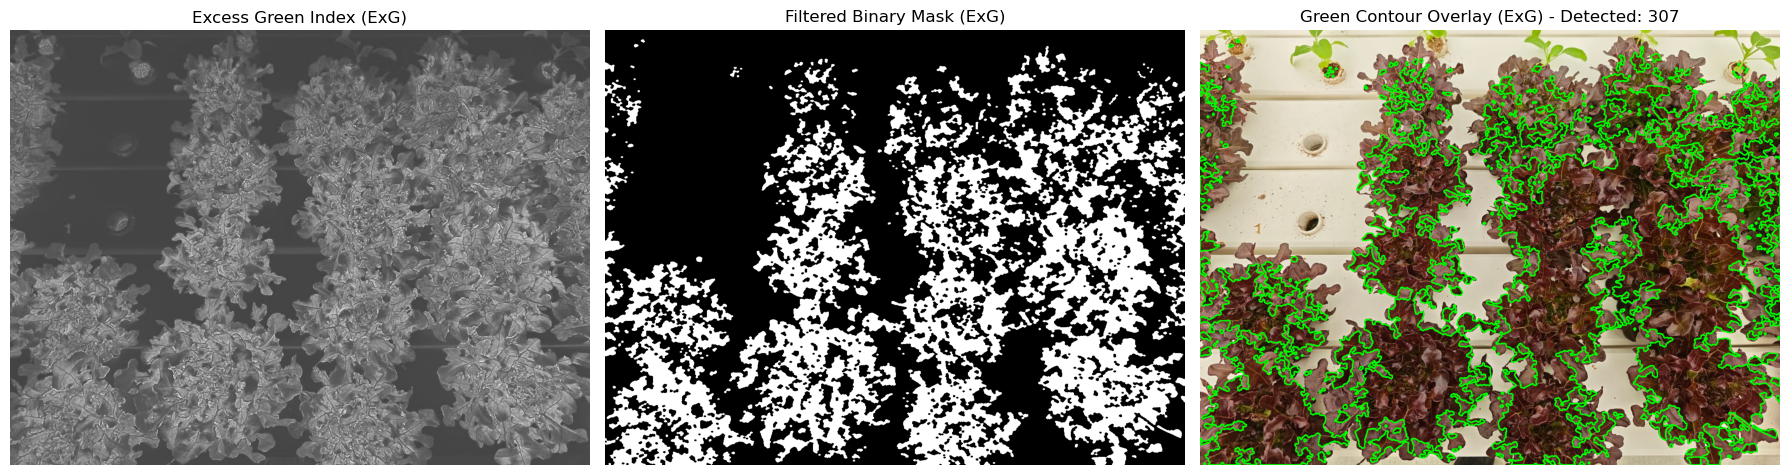

In [115]:
print("========================================")
print("Excess Green Index: ExG")
print("========================================")

# 1. Split channels
r, g, b = cv2.split(img_rgb)

# 2. Calculate normalized chromaticities: r = R/(R+G+B), g = G/(R+G+B), b = B/(R+G+B)
r_f = r.astype(np.float32)
g_f = g.astype(np.float32)
b_f = b.astype(np.float32)
total = r_f + g_f + b_f
total[total == 0] = 1.0

r_norm = r_f / total
g_norm = g_f / total
b_norm = b_f / total

# 3. Compute Excess Green Index: ExG = 2*g - r - b
exg = 2.0 * r_norm - g_norm - b_norm

# Scale ExG to 0-255 range
exg_min = exg.min()
exg_max = exg.max()
exg_scaled = np.uint8(255 * (exg - exg_min) / (exg_max - exg_min + 1e-8))

# 4. Apply Otsu's Thresholding
ret, thresh = cv2.threshold(exg_scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"[ExG] Otsu threshold value: {ret}")

# 5. Morphological Cleaning
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

# Extract final filtered contours
final_contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on RGB image copy
img_contour = img_rgb.copy()
cv2.drawContours(img_contour, final_contours, -1, (0, 255, 0), 2)

# Plot step results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(exg_scaled, cmap='gray')
axes[0].set_title("Excess Green Index (ExG)")
axes[0].axis('off')

axes[1].imshow(cleaned, cmap='gray')
axes[1].set_title("Filtered Binary Mask (ExG)")
axes[1].axis('off')

axes[2].imshow(img_contour)
axes[2].set_title(f"Green Contour Overlay (ExG) - Detected: {len(final_contours)}")
axes[2].axis('off')

plt.tight_layout()
plt.show()